import all the necessary moduleand packages


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

load the dataset

In [ ]:
df = pd.read_csv(r"C:\Users\sama\OneDrive\Desktop\mokshmlops\Walmart.csv")
print(df.head())
print("Dataset shape:", df.shape)

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  
Dataset shape: (6435, 8)


This code performs a basic exploration of the dataset.

df.shape displays the number of rows and columns in the dataset.
df.columns displays the names of all columns.
df.dtypes shows the data type of each column.
df.describe() provides a statistical summary of the numerical columns, including count, mean, standard deviation, minimum, and maximum values.

In [ ]:
print("Dataset Shape:")
print(df.shape)
print("\nColumn Names:")
print(df.columns)
print("\nData Types:")
print(df.dtypes)
print("\nStatistical Summary:")
display(df.describe())

Dataset Shape:
(6435, 8)

Column Names:
Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='str')

Data Types:
Store             int64
Date                str
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

Statistical Summary:


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


Checking Missing and Duplicate Values
This code checks the dataset for data quality issues.
* df.isnull().sum() displays the number of missing values in each column.
* df.duplicated().sum() displays the total number of duplicate rows in the dataset.
This helps identify problems that may need to be handled during data preprocessing.

In [ ]:
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Duplicate Rows:
0


# Removing Duplicate Rows
This code removes duplicate rows from the dataset using `df.drop_duplicates()`.
After removing duplicates, `df.shape` displays the updated number of rows and columns. This helps ensure that the dataset contains unique records before further preprocessing and model training.


In [ ]:
df = df.drop_duplicates()
print("Dataset shape after removing duplicates:")
print(df.shape)

Dataset shape after removing duplicates:
(6435, 8)


# Converting the Date Column
This code converts the `Date` column from text format into the proper **datetime format**.
* `format="%d-%m-%Y"` specifies that the date is in **day-month-year** format.
* `errors="coerce"` converts invalid date values into missing (`NaT`) values instead of causing an error.
* `df.dtypes` displays the updated data types of all columns.
This makes the `Date` column suitable for further date-based analysis and feature extraction.

In [ ]:
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

print("Invalid dates:", df["Date"].isna().sum())
print(df.dtypes)

Invalid dates: 0
Store                    int64
Date            datetime64[us]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object


# Extracting Date Features
This code extracts useful information from the `Date` column and creates new features:
* **Year** – Extracts the year from the date.
* **Month** – Extracts the month number.
* **Week** – Extracts the week number of the year.
* **Day** – Extracts the day of the month.
* **Quarter** – Extracts the quarter of the year.
After extracting these features, the original `Date` column is removed because its information is now represented in separate numerical columns.
Finally, `df.head()` displays the first five rows of the updated dataset.

In [ ]:
# Remove rows with invalid dates, if any
df = df.dropna(subset=["Date"]).copy()

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Date"].dt.day
df["Quarter"] = df["Date"].dt.quarter

df = df.drop("Date", axis=1)

display(df.head())

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Day,Quarter
0,1,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,5,1
1,1,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,12,1
2,1,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,19,1
3,1,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,26,1
4,1,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,5,1


# Handling Missing Values
This code checks for missing values in the dataset and handles them using the **median value** of each column.
* First, it displays the number of missing values in each column.
* For columns containing missing values, the missing entries are replaced with the column's median.
* Finally, the code checks and displays the remaining missing values after preprocessing.
Using the median helps handle missing numerical data without being heavily affected by outliers.


In [ ]:
print("Missing values before handling:")
print(df.isnull().sum())

numeric_features = df.select_dtypes(include=np.number).columns

for column in numeric_features:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

print("\nMissing values after preprocessing:")
print(df.isnull().sum())

Missing values before handling:
Store           0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Year            0
Month           0
Week            0
Day             0
Quarter         0
dtype: int64

Missing values after preprocessing:
Store           0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Year            0
Month           0
Week            0
Day             0
Quarter         0
dtype: int64


# Separating Features and Target Variable
This code separates the dataset into **input features** and the **target variable**.
* `y` stores the `Weekly_Sales` column, which is the value the model will predict.
* `X` contains all remaining columns, which are used as input features for the model.
* `X.columns` displays the names of all features used for prediction.
This prepares the dataset for training a machine learning model.

In [ ]:
y = df["Weekly_Sales"]
X = df.drop("Weekly_Sales", axis=1)

print("Features Used:")
print(X.columns.tolist())
print("\nTarget: Weekly_Sales")

Features Used:
['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Week', 'Day', 'Quarter']

Target: Weekly_Sales


# Splitting the Dataset
This code splits the dataset into **training data** and **testing data**.
* **80% of the data** is used for training the machine learning model.
* **20% of the data** is used for testing the model's performance.
* `random_state=42` ensures that the same data split is produced every time the code is executed.
Finally, the code displays the shape of the training and testing datasets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (5148, 11)
Testing Data Shape: (1287, 11)


# Feature Scaling
This code standardizes the input features using `StandardScaler`.
* `fit_transform()` calculates the mean and standard deviation from the training data and scales it.
* `transform()` applies the same scaling to the testing data.
Feature scaling helps ensure that all numerical features are on a similar scale, which can improve the performance of certain machine learning models.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")

Scaling completed successfully.


# Defining Machine Learning Models
This code creates a collection of different regression models for predicting `Weekly_Sales`.
The models included are:
* **Linear Regression** – A simple model that predicts values based on linear relationships.
* **Random Forest Regressor** – Uses multiple decision trees to improve prediction accuracy.
* **Extra Trees Regressor** – Builds multiple randomized decision trees for prediction.
* **Gradient Boosting Regressor** – Builds models sequentially to improve prediction performance.
The parameters such as `n_estimators`, `learning_rate`, and `max_depth` are used to control the model training process and improve performance.

In [ ]:
models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

print("Models:", list(models.keys()))

Models: ['Linear Regression', 'Random Forest', 'Extra Trees', 'Gradient Boosting']


# Training and Evaluating the Models
This code trains each regression model and evaluates its performance on the testing data.
* **Linear Regression** is trained using the scaled training and testing data.
* The other models are trained using the original data.
* Predictions are generated for each model.
* The models are evaluated using:
  * **MAE** – Average prediction error.
  * **MSE** – Average squared prediction error.
  * **RMSE** – Square root of MSE, showing the prediction error in the original units.
  * **R² Score** – Measures how well the model explains the variation in the target variable.
The results are stored in a DataFrame and sorted by the **R² Score** in descending order, so the best-performing model appears at the top.

In [ ]:
results = []

for name, model in models.items():

    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2,
        "R2 Percentage": r2 * 100
    })

results_df = pd.DataFrame(results).sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,MAE,MSE,RMSE,R2 Score,R2 Percentage
0,Extra Trees,52575.117617,1.026621e+10,101322.313830,0.968133,96.813265
1,Random Forest,53658.532127,1.108354e+10,105278.400163,0.965596,96.559558
2,Gradient Boosting,162448.334041,4.502586e+10,212192.970686,0.860235,86.023524
3,Linear Regression,433278.641528,2.723453e+11,521867.100094,0.154613,15.461303


# Select the best regression model using the highest R² score.
# For regression, R² is the appropriate "performance" metric;
# classification accuracy and precision are not appropriate here.

In [ ]:
best_model_name = results_df.loc[0, "Model"]

print("Best Model:", best_model_name)
print("\nBest Model Performance:")
display(results_df.iloc[[0]])

Best Model: Extra Trees

Best Model Performance:


,Model,MAE,MSE,RMSE,R2 Score,R2 Percentage
0,Extra Trees,52575.117617,1.026621e+10,101322.31383,0.968133,96.813265


# Training the Best Model
This code selects the best-performing model based on the previously identified `best_model_name`.
* The selected model is stored in `best_model`.
* If the best model is **Linear Regression**, it is trained using the scaled training data.
* For other models, the original training data is used.
* The trained model then makes predictions on the testing data, which are stored in `y_pred`.
These predictions are used for further evaluation of the final model.

In [ ]:
best_model = models[best_model_name]

if best_model_name == "Linear Regression":
    best_model.fit(X_train_scaled, y_train)
    y_pred = best_model.predict(X_test_scaled)
else:
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)

print("Best model trained successfully.")

Best model trained successfully.


# Final Model Performance
This code evaluates the performance of the selected best model using the test data.
The following metrics are calculated:
* **MAE** – Measures the average prediction error.
* **MSE** – Measures the average squared prediction error.
* **RMSE** – Shows the prediction error in the original units.
* **R² Score** – Shows how well the model explains the variation in `Weekly_Sales`.
The results are rounded and displayed to provide a clear summary of the final model's performance.

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Optional error-based percentage for easy reporting.
# This is NOT classification accuracy or precision.
mean_sales = np.mean(np.abs(y_test))
error_percentage = (mae / mean_sales) * 100
accuracy_like = 100 - error_percentage

print("\nBest Model Evaluation Metrics:")
print("Best Model       :", best_model_name)
print("MAE              :", round(mae, 2))
print("MSE              :", round(mse, 2))
print("RMSE             :", round(rmse, 2))
print("R² Score         :", round(r2, 4))
print("R² Percentage    :", round(r2 * 100, 2), "%")
print("MAE Error (%)    :", round(error_percentage, 2), "%")
print("Error-based score:", round(accuracy_like, 2), "%")


Best Model Evaluation Metrics:
Best Model       : Extra Trees
MAE              : 52575.12
MSE              : 10266211279.88
RMSE             : 101322.31
R² Score         : 0.9681
R² Percentage    : 96.81 %
MAE Error (%)    : 4.98 %
Error-based score: 95.02 %


# Actual vs Predicted Sales Visualization
This code creates a line graph to compare the **actual weekly sales** with the **predicted weekly sales**.
* A DataFrame is created containing both actual and predicted sales values.
* The first 100 test samples are selected for better visualization.
* The graph displays actual sales as a solid line and predicted sales as a dashed line.
* Labels, a title, legend, and grid are added to make the graph easier to understand.
This visualization helps compare how closely the model's predictions match the actual sales values.

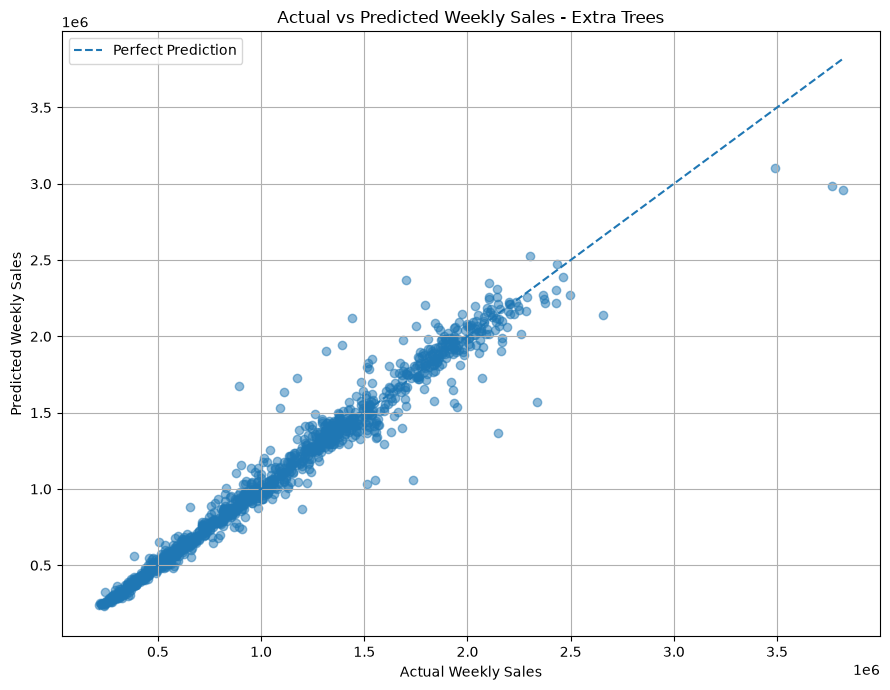

In [ ]:
comparison_df = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

plt.figure(figsize=(9, 7))

plt.scatter(
    comparison_df["Actual Sales"],
    comparison_df["Predicted Sales"],
    alpha=0.5
)

minimum = min(
    comparison_df["Actual Sales"].min(),
    comparison_df["Predicted Sales"].min()
)
maximum = max(
    comparison_df["Actual Sales"].max(),
    comparison_df["Predicted Sales"].max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title(f"Actual vs Predicted Weekly Sales - {best_model_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Comparing Model Performance
This code creates a bar chart to compare the performance of all regression models using their **R² Score**.
* Each bar represents a machine learning model.
* The height of the bar represents the model's R² Score.
* The model names are rotated slightly for better readability.
This visualization makes it easy to identify and compare which regression model performs better.

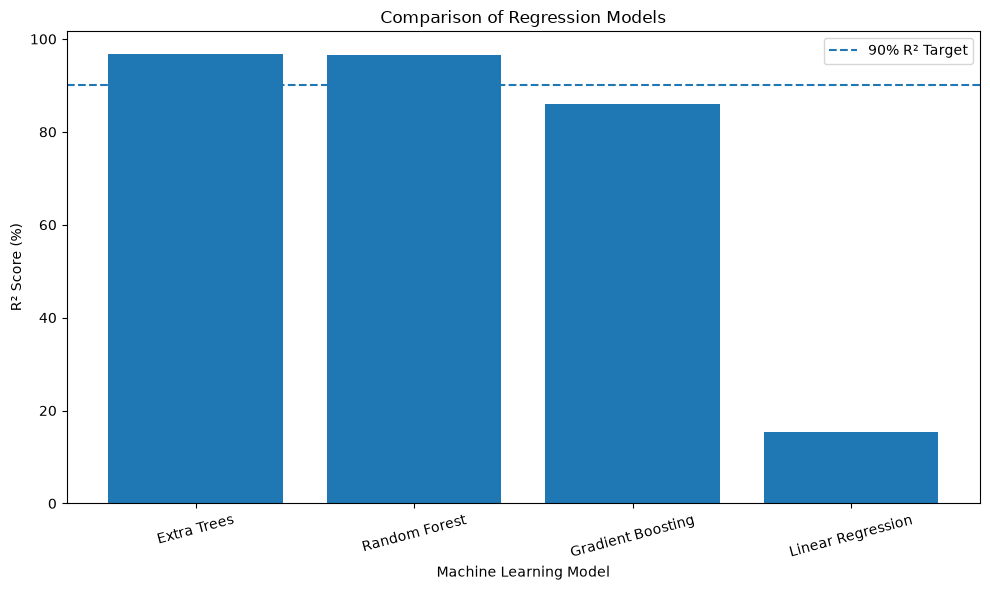

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["R2 Percentage"]
)

plt.axhline(
    y=90,
    linestyle="--",
    label="90% R² Target"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("R² Score (%)")
plt.title("Comparison of Regression Models")
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

best_r2 = results_df.loc[0, "R2 Percentage"]

print(f"Conclusion: {best_model_name} is the best-performing model because it achieved the highest R² score of {best_r2:.2f}%.")

if best_r2 >= 90:
    print("The best model meets the target of approximately 90% R² performance.")
else:
    print("The best model does not reach 90% R² on this feature set. Do not change the score manually; improve feature engineering or model tuning instead.")

print("For this regression task, R², MAE, and RMSE should be used as the main evaluation metrics.")